In [2]:
import numpy as n
import matplotlib.pyplot as plt
from astropy.modeling.functional_models import Gaussian2D

# Establishing Detector Size and x,y grid

In [3]:
x_dim = 500
y_dim = 500
detector = n.zeros((y_dim, x_dim))

ydim_arr = n.arange(y_dim)
xdim_arr = n.arange(x_dim)
x_grid, y_grid = n.meshgrid(xdim_arr,ydim_arr)

# Make Noise Background

In [8]:
background_mean = 0
background_sigma = 10
background = n.random.normal(background_mean, background_sigma, size = detector.shape)

# Make Star Image (2D Gaussian)

In [9]:
star_amplitude = 50 # Gaussian amplitude
star_sigma = 10     # Gaussian sigma in x and y
star_function = Gaussian2D(amplitude=star_amplitude, x_mean = 250, y_mean = 250, x_stddev=star_sigma, y_stddev=star_sigma) 
star_image = star_function(x_grid, y_grid)

# Combine Star Signal and Background

In [17]:
combined_image = background + star_image

# Plot Image

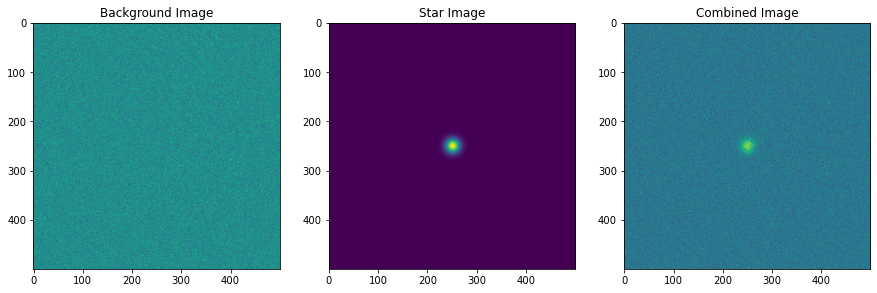

In [21]:
plt.figure('detector simulation', figsize = (15,5))
plt.subplot(131)
plt.title('Background Image')
plt.imshow(background)

plt.subplot(132)
plt.title('Star Image')
plt.imshow(star_image)

plt.subplot(133)
plt.title('Combined Image')
plt.imshow(combined_image)
plt.show()

# Plot Histogram of Counts

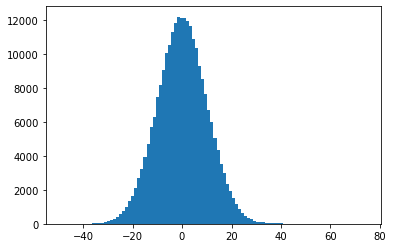

In [28]:
samples = n.ndarray.flatten(combined_image)

plt.figure('historgram')
plt.hist(samples, bins = 100, align = 'mid')
plt.show()

In [30]:
print('standard deviation: ' + str(n.std(samples)))
print('mean: ' + str(n.mean(samples)))

standard deviation: 10.151714671037293
mean: 0.12490378021680024
